# Analysis of EG01-EG23 Cyclus scenario with Cymetric
Cymetric provides a python-based way to interact with your Cyclus SQLite 
output file. There are various "metrics" in Cymetric, which pull data from 
different tables in the output, and other metrics that combine tables 
to produce other metrics. 

The analysis problems explored in this workshop include:
* Visualizing the fuel cycle modeled in the scenario
* Plotting the number of reactors deployed against the 
  amount of electricity generated
* Plotting the amount of fresh fuel sent to each reactor prototype

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cymetric as cym # Use an alias for cymetric
from cymetric import graphs

/root/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Open the output file with Cymetric
database = cym.dbopen('eg01-eg23.sqlite')
# Define the Evaluator Object 
eg23_evaluator = cym.Evaluator(database, write=False) #Don't write metrics to the database

## Visualize the fuel cycle scenario

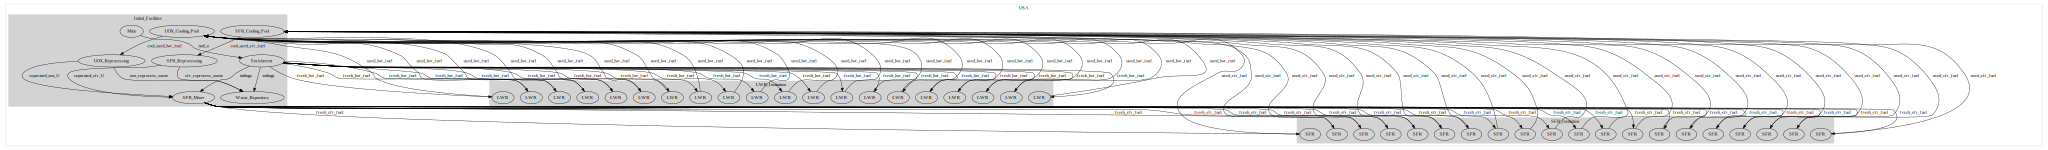

In [3]:
# Create a flow graph from the evaluator object
graphs.flow_graph(eg23_evaluator, label='comm')

That ones looks a little messy, showing each of the reactor 
agents as a sepearate node on the figure. The course instructors 
created an even more simple fuel cycle to make this figure easier 
to read. The figure below shows a simplified view of the fuel 
cycle in this input:
![Fuel cycle diagram, with prototypes deployed multiple times condensed to one node](./eg01-eg23_graph.jpg)


## Compare the number of reactors and the amount of electricity produced
We have different metrics we will look at for this: 
* `BuildSeries`, to get the number of reactors that are commissioned
* `DecommissionSeries`, to get the number of reactors that are decommissioned
* `MonthlyElectricityGeneratedByAgent`, to get the amount of electircity 
  generated by the reactors each year.

First, we will pull the `BuildSeries` metric, and sort out the data into the 
different prototypes. Second, we will pull the `DecommissionSeries` metric
and sort the data into different prototypes. Then, we will combine 
the `BuildSeries` and `DecommissionSeries` metrics to calculate the 
number of reactors deployed as a function of time. 

For the electricity generation data, we will pull the 
`MonthlyElectricityGeneratedByAgent` metric and sum the data across 
all agents to yield the total electircity generated as a function 
of timestep. 

Finally, we will plot both sets of data (the total number of reactors 
deployed and the electricity generated) on the same plot, using two 
different axes. 

In [4]:
# Get all BuildSeries data, then sort into LWR and SFR deployments
build_series = eg23_evaluator.eval('BuildSeries')
lwr_build = build_series.loc[build_series['Prototype'] == 'LWR']
sfr_build = build_series.loc[build_series['Prototype'] == 'SFR']

# Get the DecomSeries data, and split by prototype. 
decom_series = eg23_evaluator.eval('DecommissionSeries')
lwr_decom = decom_series.loc[decom_series['Prototype'] == 'LWR']
sfr_decom = decom_series.loc[decom_series['Prototype'] == 'SFR']
# Multiply by negative one to count them as exiting the simulation
# This step makes it easier to add things
lwr_decom['Count'] *= -1
sfr_decom['Count'] *= -1

In [5]:
# Get a timeseries of the number of each reactor prototype 
# deployed in each time step. 
lwr_number = np.zeros(1200)
for variable in [lwr_build, lwr_decom]:
    for row in variable.itertuples():
        time_step = row[2]
        lwr_number[time_step:] += row[4]

sfr_number = np.zeros(1200)
for variable in [sfr_build, sfr_decom]:
    for row in variable.itertuples():
        time_step = row[2]
        sfr_number[time_step:] += row[4]
        
reactors_deployed = pd.DataFrame(data = {'Time': np.linspace(0,1199, 1200),
                                         'lwr':lwr_number,
                                         'sfr':sfr_number})

In [6]:
# Get electiricty generated and sum across time steps. 
all_electricity = eg23_evaluator.eval('MonthlyElectricityGeneratedByAgent')
summed_electricity = all_electricity[['Month', 'Energy']].groupby(by=['Month']).sum()

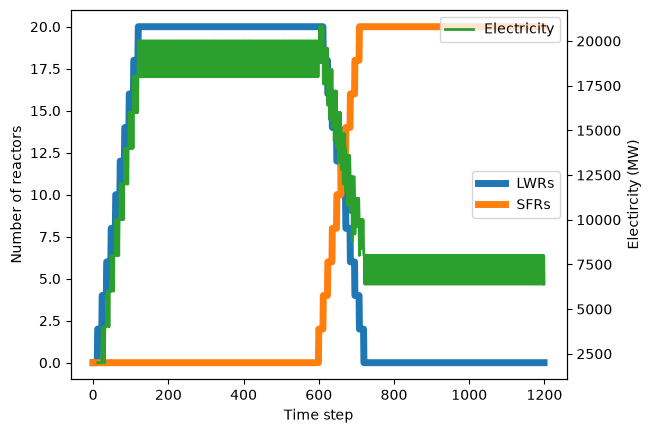

In [7]:
# Let's plot our data!
fig, ax1 = plt.subplots()

ax1.plot(reactors_deployed['Time'], reactors_deployed['lwr'], linewidth=5)
ax1.plot(reactors_deployed['Time'], reactors_deployed['sfr'], linewidth=5)
ax1.set_xlabel('Time step')
ax1.set_ylabel('Number of reactors')


ax2 = ax1.twinx()
ax2.plot(summed_electricity['Energy'], 
         color='tab:green', linewidth=2)
ax2.set_ylabel('Electircity (MW)')

ax1.legend(['LWRs', 'SFRs'])
ax2.legend(['Electricity'])

## Material transactions 
This section does analysis on the materials traded between 
facilities in the fuel cycle scenario. This analysis is done 
with the `TransactionQuantity` metric, which provides the mass 
of a commodity in each transaction. 

For this analysis, we'll pull the `TransactionQuantity` metric, which 
merges the `Transactions` and `Materials` tables from the database. Then 
we will pull out just the information pertaining to the commodities that 
we care about -- the `fresh_lwr_fuel` and the `fresh_sfr_fuel`. The 
resulting table only has data at the timesteps in which the material 
is traded, which makes the graphs look like a straight line. So we need
to add in the other time steps and specify that nothing is traded 
at those times. Then we can plot things. 


In [8]:
# We pull the TransactionQuantity metric
trans_quantity = eg23_evaluator.eval('TransactionQuantity')
fresh_fuel_names = ['fresh_lwr_fuel', 'fresh_sfr_fuel']
commodity_trans ={}
for commodity_name in fresh_fuel_names:
    commodity_trans[commodity_name] = trans_quantity.loc[trans_quantity['Commodity'] == commodity_name]
    commodity_trans[commodity_name] = commodity_trans[commodity_name].groupby(['TimeCreated']).Quantity.sum().reset_index()
    commodity_trans[commodity_name] = commodity_trans[commodity_name].set_index('TimeCreated').reindex(np.arange(0,1199,1)).fillna(0).reset_index()

Text(0, 0.5, 'Mass (kg)')

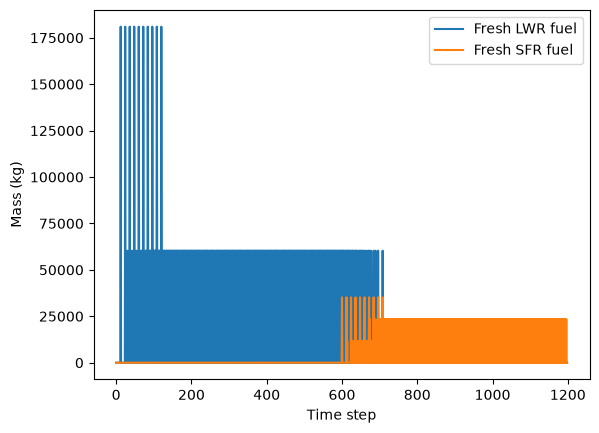

In [9]:
plt.figure()
for commodity in fresh_fuel_names:
    plt.plot(commodity_trans[commodity]['TimeCreated'],
            commodity_trans[commodity]['Quantity'])
plt.legend(['Fresh LWR fuel', 'Fresh SFR fuel'])
plt.xlabel('Time step')
plt.ylabel('Mass (kg)')